## Load and apply inference models
This notebook loads trained inference models from the outputs of `cmass.infer.train`, plots their prediction performance, and applies them to new test data.

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from os.path import join
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
mpl.style.use('../../style.mcstyle')   # noqa
import numpy as np
import torch
import seaborn as sns
import pandas as pd
import warnings
from tqdm import tqdm

from tools import torch_device

device = torch_device()

# Suppress warnings
warnings.filterwarnings('ignore')

Duplicate key in file '../../style.mcstyle', line 16 ('font.family: serif')


CUDA is not available. Using CPU.


## Load a model

In [2]:
wdir = '/anvil/scratch/x-mho1/cmass-ili'

cosmonames = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$']
hodnames = [r'$\alpha$', r'$\log M_0$', r'$\log M_1$',
            r'$\log M_{\min}$', r'$\sigma_{\log M}$']
names = cosmonames  # +hodnames

# Specify model configuration
nbody = 'mtnglike'
sim = 'fastpm_hodzbias'
save_dir = join(wdir, nbody, sim, 'models')

# Specify data dtype
# tracer = 'halo'
tracer = 'galaxy'
summaries = ['nbar', 'zPk0', 'zPk2', 'zPk4']  # ,  'zEqQk0']
# summaries = ['Pk0', 'Pk2', 'Pk4', 'Qk0']
summary = '+'.join(summaries)
kmin, kmax = 0.0, 0.4
modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')
print(
    f'Loading model: nbody={nbody}, sim={sim}, tracer={tracer}, \n\tsummary={summary}, kmin={kmin}, kmax={kmax}')
print('\n'.join(os.listdir(modelpath)))

Loading model: nbody=mtnglike, sim=fastpm_hodzbias, tracer=galaxy, 
	summary=nbar+zPk0+zPk2+zPk4, kmin=0.0, kmax=0.4
x_val.npy
posterior.pkl
true_logprobs.npy
ids_test.npy
plot_hyperparam_dependence.jpg
theta_train.npy
plot_coverage.jpg
theta_test.npy
x_test.npy
nets
plot_true_logprobs.jpg
ids_train.npy
theta_val.npy
ranks_histogram.jpg
plot_single_posterior.jpg
x_train.npy
plot_TARP.jpg
optuna_study.db
plot_predictions.jpg
ids_val.npy
posterior_samples.npy


In [3]:
# Load predictions
xtest = np.load(join(modelpath, 'x_test.npy'))
ytest = np.load(join(modelpath, 'theta_test.npy'))
samps = np.load(join(modelpath, 'posterior_samples.npy'))
percs = np.percentile(samps, [16, 50, 84], axis=0)

yrange = np.stack([
    ytest.min(axis=0),
    ytest.max(axis=0)
], axis=1)

Text(0.5, 0.98, 'galaxy nbar+zPk0+zPk2+zPk4 predictions')

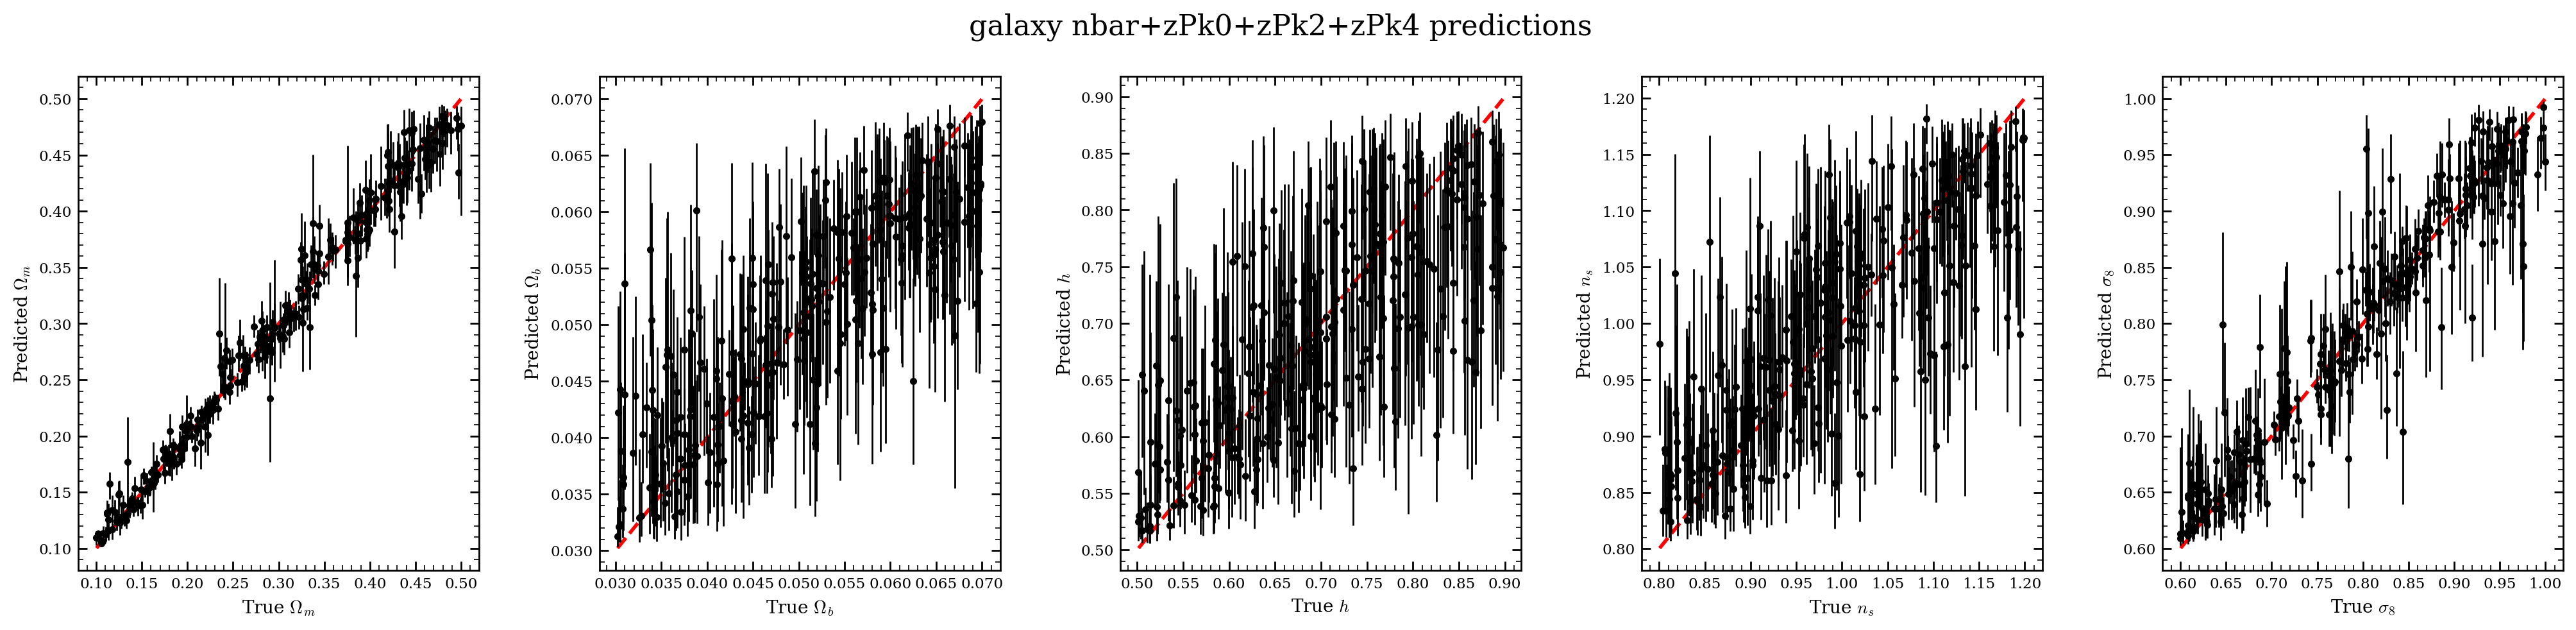

In [4]:
ss = 5

N = len(names)
H, W = N//5, 5
f, axs = plt.subplots(H, W, figsize=(5*W, 5*H), gridspec_kw=dict(wspace=0.3))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i >= N:
        ax.axis('off')
        continue
    ax.plot(yrange[i], yrange[i], 'r--')
    ax.plot(ytest[::ss, i], percs[1, ::ss, i], 'k.')
    ax.errorbar(ytest[::ss, i], percs[1, ::ss, i], yerr=[percs[1, ::ss, i]-percs[0, ::ss, i],
                percs[2, ::ss, i]-percs[1, ::ss, i]], fmt='none', ecolor='k', elinewidth=1)
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')
f.suptitle(f'{tracer} {summary} predictions', fontsize=16)

In [5]:
# Load literature data
lit_path = join(wdir, 'literature', 'processed')

# SimBIG zPk024
filename = join(lit_path, 'simbig_pk.csv')
simpk = pd.read_csv(filename)
simpk.columns = names
simpk['Model'] = 'SimBIG zPk024'

# SimBIG zQk0
filename = join(lit_path, 'simbig_bk.csv')
simbk = pd.read_csv(filename)
simbk.columns = names
simbk['Model'] = 'SimBIG zQk0'

# print(simpk.shape, simbk.shape)
# simbk

Text(0.5, 0.98, 'galaxy nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$')

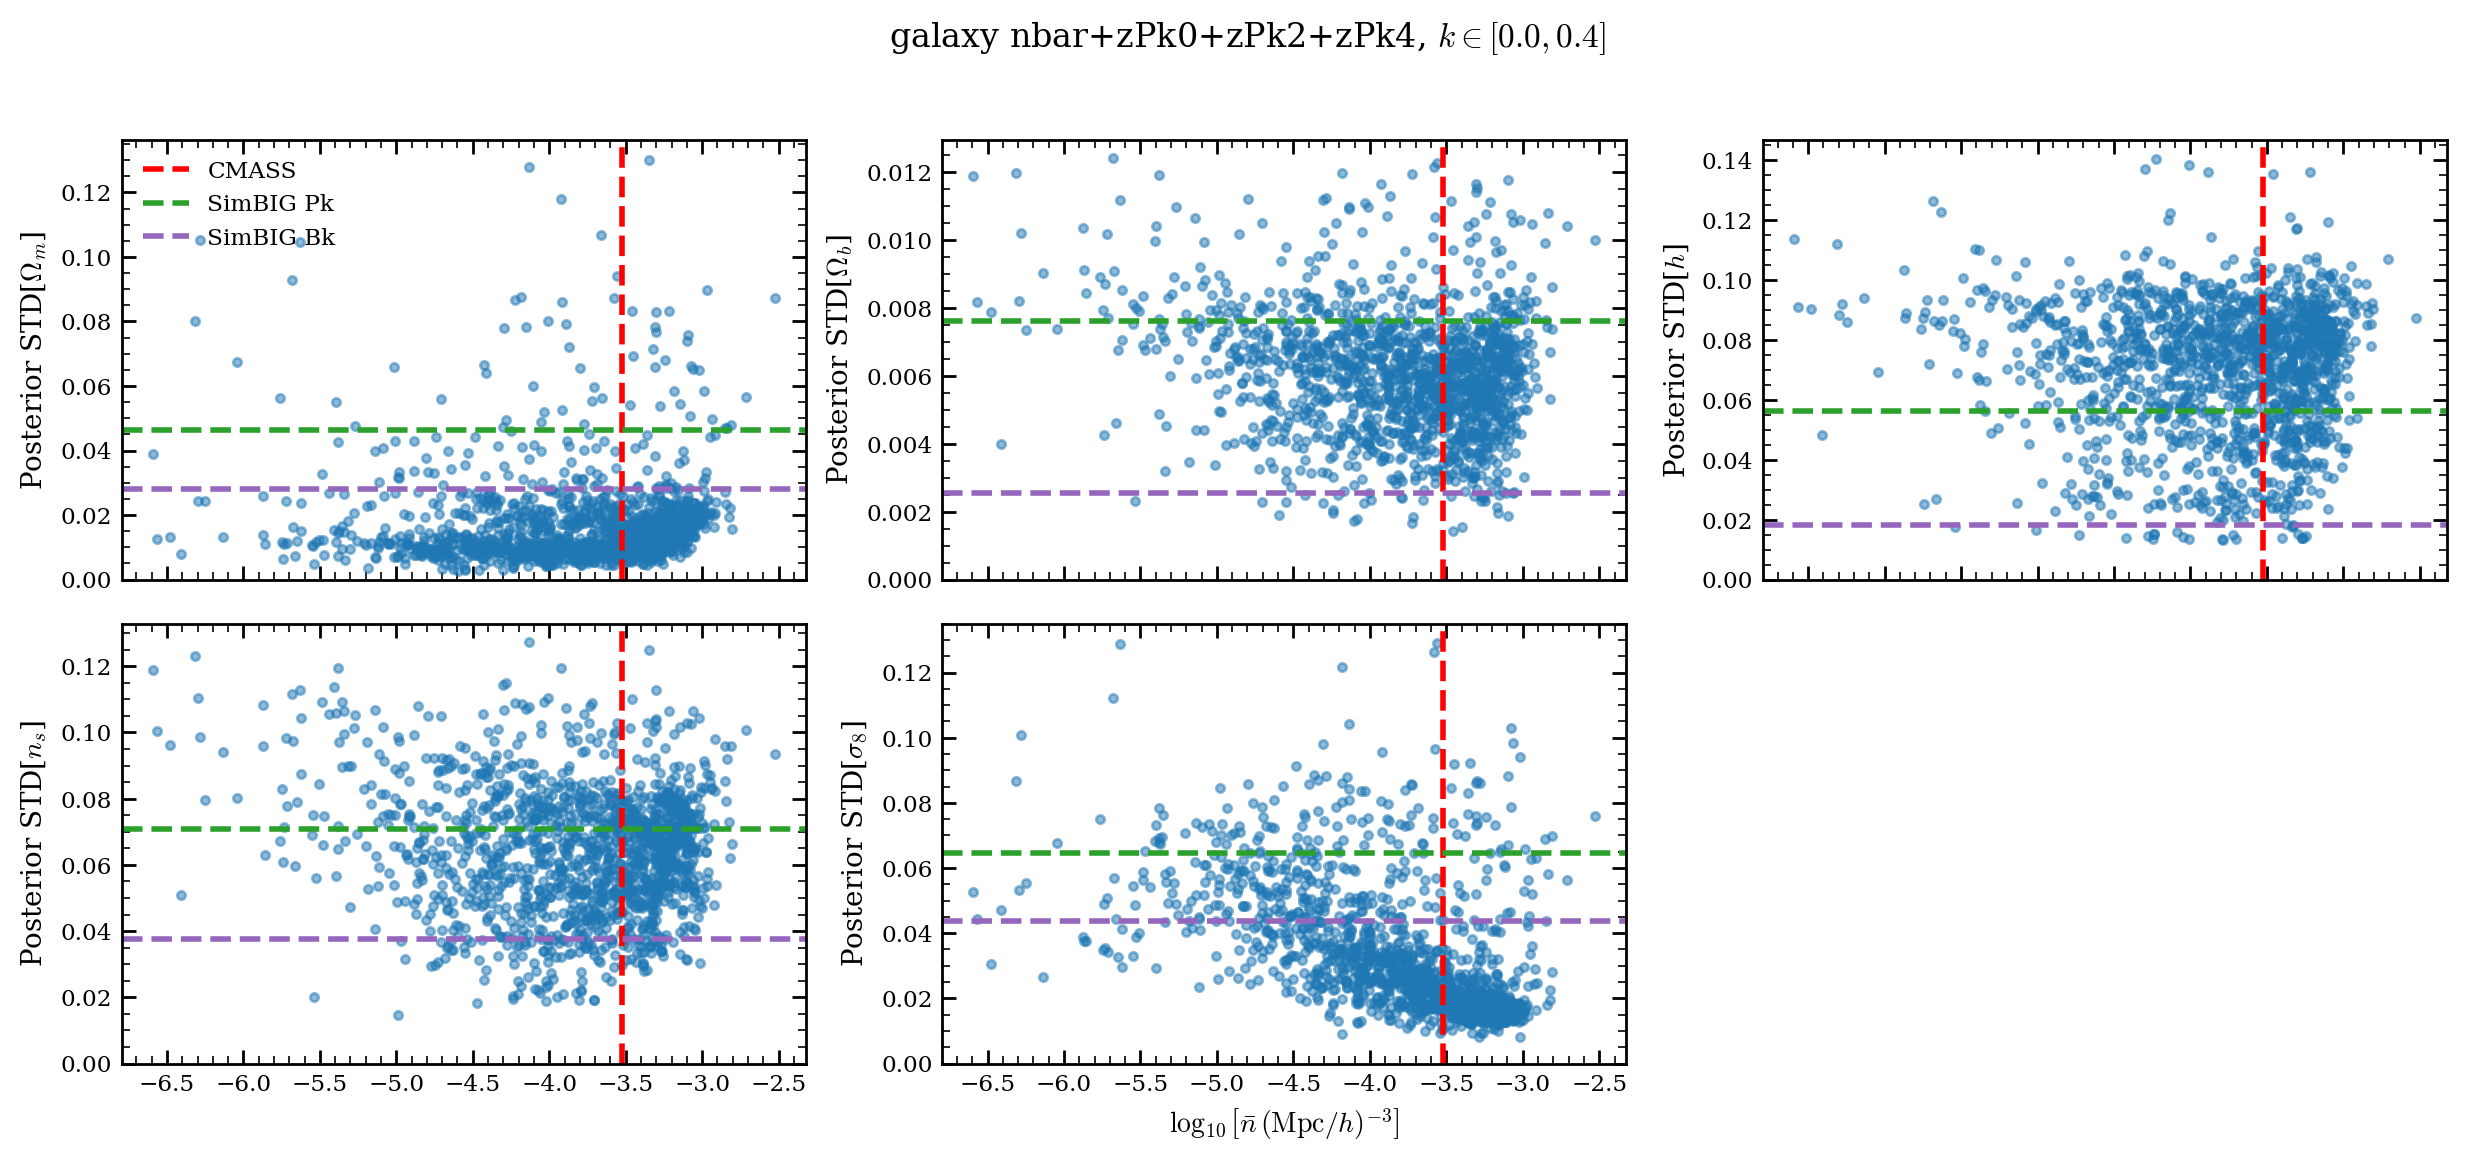

In [6]:
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

nbar_CMASS = np.log10(3e-4)
sb_pkstd = np.std(simpk.values[:, :-1].astype(float), axis=0)
sb_bkstd = np.std(simbk.values[:, :-1].astype(float), axis=0)

W = 3
H = len(names) // W + (len(names) % W > 0)

f, axs = plt.subplots(H, W, figsize=(5*W, 3*H),
                      sharex=True,
                      gridspec_kw=dict(hspace=0.1))
axs = axs.flatten()
for i, ax in enumerate(axs):
    if i >= len(names):
        ax.axis('off')
        continue
    ax.plot(xtest[:, -1], samps.std(axis=0)[:, i], '.', alpha=0.5)
    ax.axvline(nbar_CMASS, color='r', ls='--', label='CMASS')
    ax.axhline(sb_pkstd[i], color='C2', ls='--', label='SimBIG Pk')
    ax.axhline(sb_bkstd[i], color='C4', ls='--', label='SimBIG Bk')
    ax.set_ylabel(f'Posterior STD[{names[i]}]')
    ax.set_ylim(0)
    if i == len(names) - 1:
        ax.set_xlabel(r'$\log_{10}\left[\bar{n}\, ({\rm Mpc}/h)^{-3}\right]$')
    if i == 0:
        ax.legend()

f.suptitle(
    f'{tracer} ' + '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$')

In [7]:
from tools import load_posterior

posterior = load_posterior(modelpath)
for p in posterior.posteriors:
    print(type(p.nde.flow))

<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>
<class 'zuko.flows.spline.NSF'>


100%|██████████| 20/20 [00:00<00:00, 140.79it/s]


[Text(0.5, 0, 'Epoch'), Text(0, 0.5, 'Log Probability')]

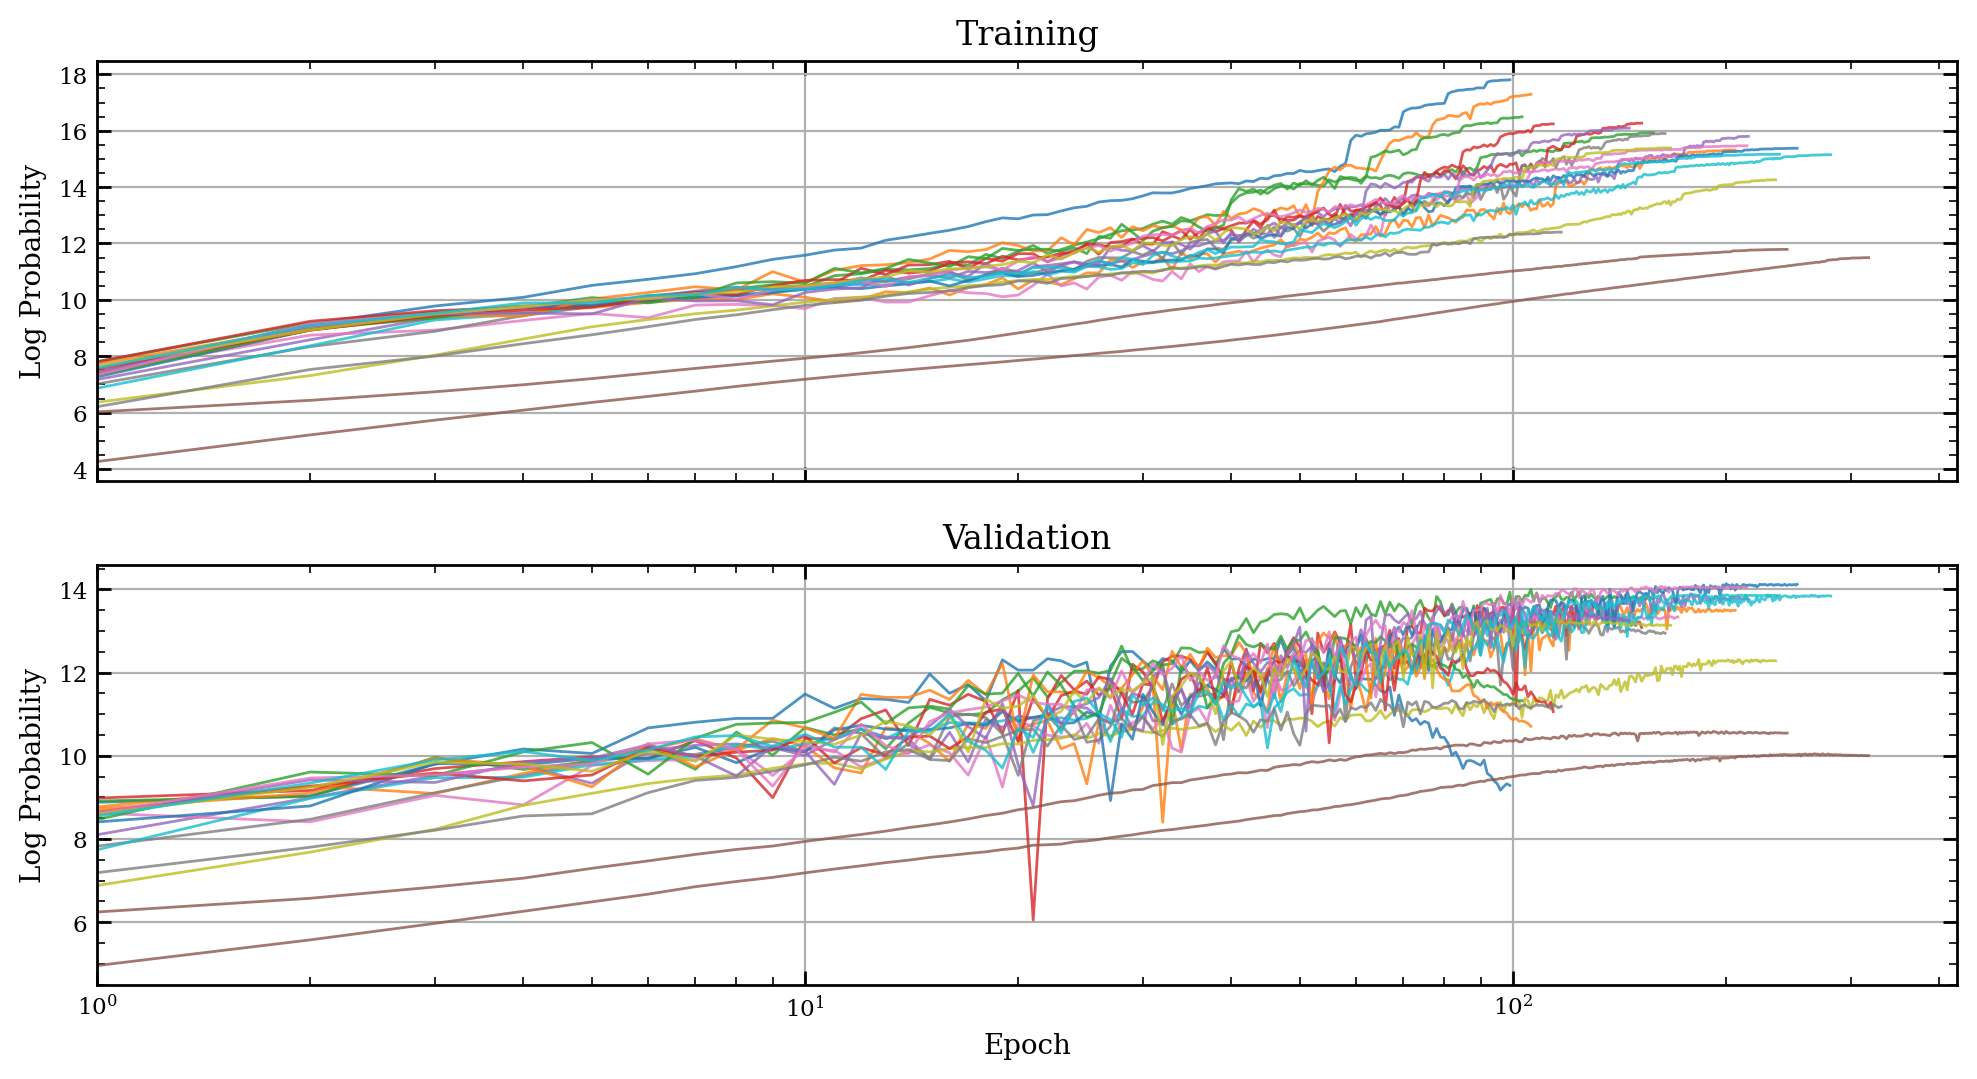

In [8]:
ss = 10

netpath = join(modelpath, 'nets')
netlist = os.listdir(netpath)

f, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for n in tqdm(netlist[::ss]):
    filepath = join(netpath, n, 'summary.json')
    if not os.path.exists(filepath):
        continue
    with open(filepath, 'r') as f:
        history = json.load(f)

    x_ = range(1, len(history[0]['training_log_probs'])+1)

    ax = axs[0]
    ax.plot(x_, history[0]['training_log_probs'], alpha=0.8, lw=1)

    ax = axs[1]
    ax.plot(x_, history[0]['validation_log_probs'], alpha=0.8, lw=1)

ax.semilogx()
ax.set_xlim(1)
# ax.set_ylim(-10, 20)

axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[0].grid()
axs[1].grid()

axs[0].set(ylabel='Log Probability')
axs[1].set(xlabel='Epoch', ylabel='Log Probability')

INFO:root:Sampling models with [231, 223, 221, 199, 193, 190, 189, 188, 187, 184] samples each.
Drawing 231 posterior samples: 440it [00:03, 137.05it/s]                        
Drawing 223 posterior samples: 439it [00:02, 180.95it/s]                         
Drawing 221 posterior samples: 439it [00:02, 208.14it/s]                         
Drawing 199 posterior samples: 394it [00:00, 1295.87it/s]                        
Drawing 193 posterior samples: 383it [00:00, 20863.66it/s]            
Drawing 190 posterior samples: 356it [00:00, 20776.30it/s]            
Drawing 189 posterior samples: 370it [00:00, 20441.96it/s]            
Drawing 188 posterior samples: 100%|██████████| 188/188 [00:00<00:00, 19809.80it/s]
Drawing 187 posterior samples: 352it [00:00, 20498.37it/s]            
Drawing 184 posterior samples: 357it [00:00, 20595.38it/s]            


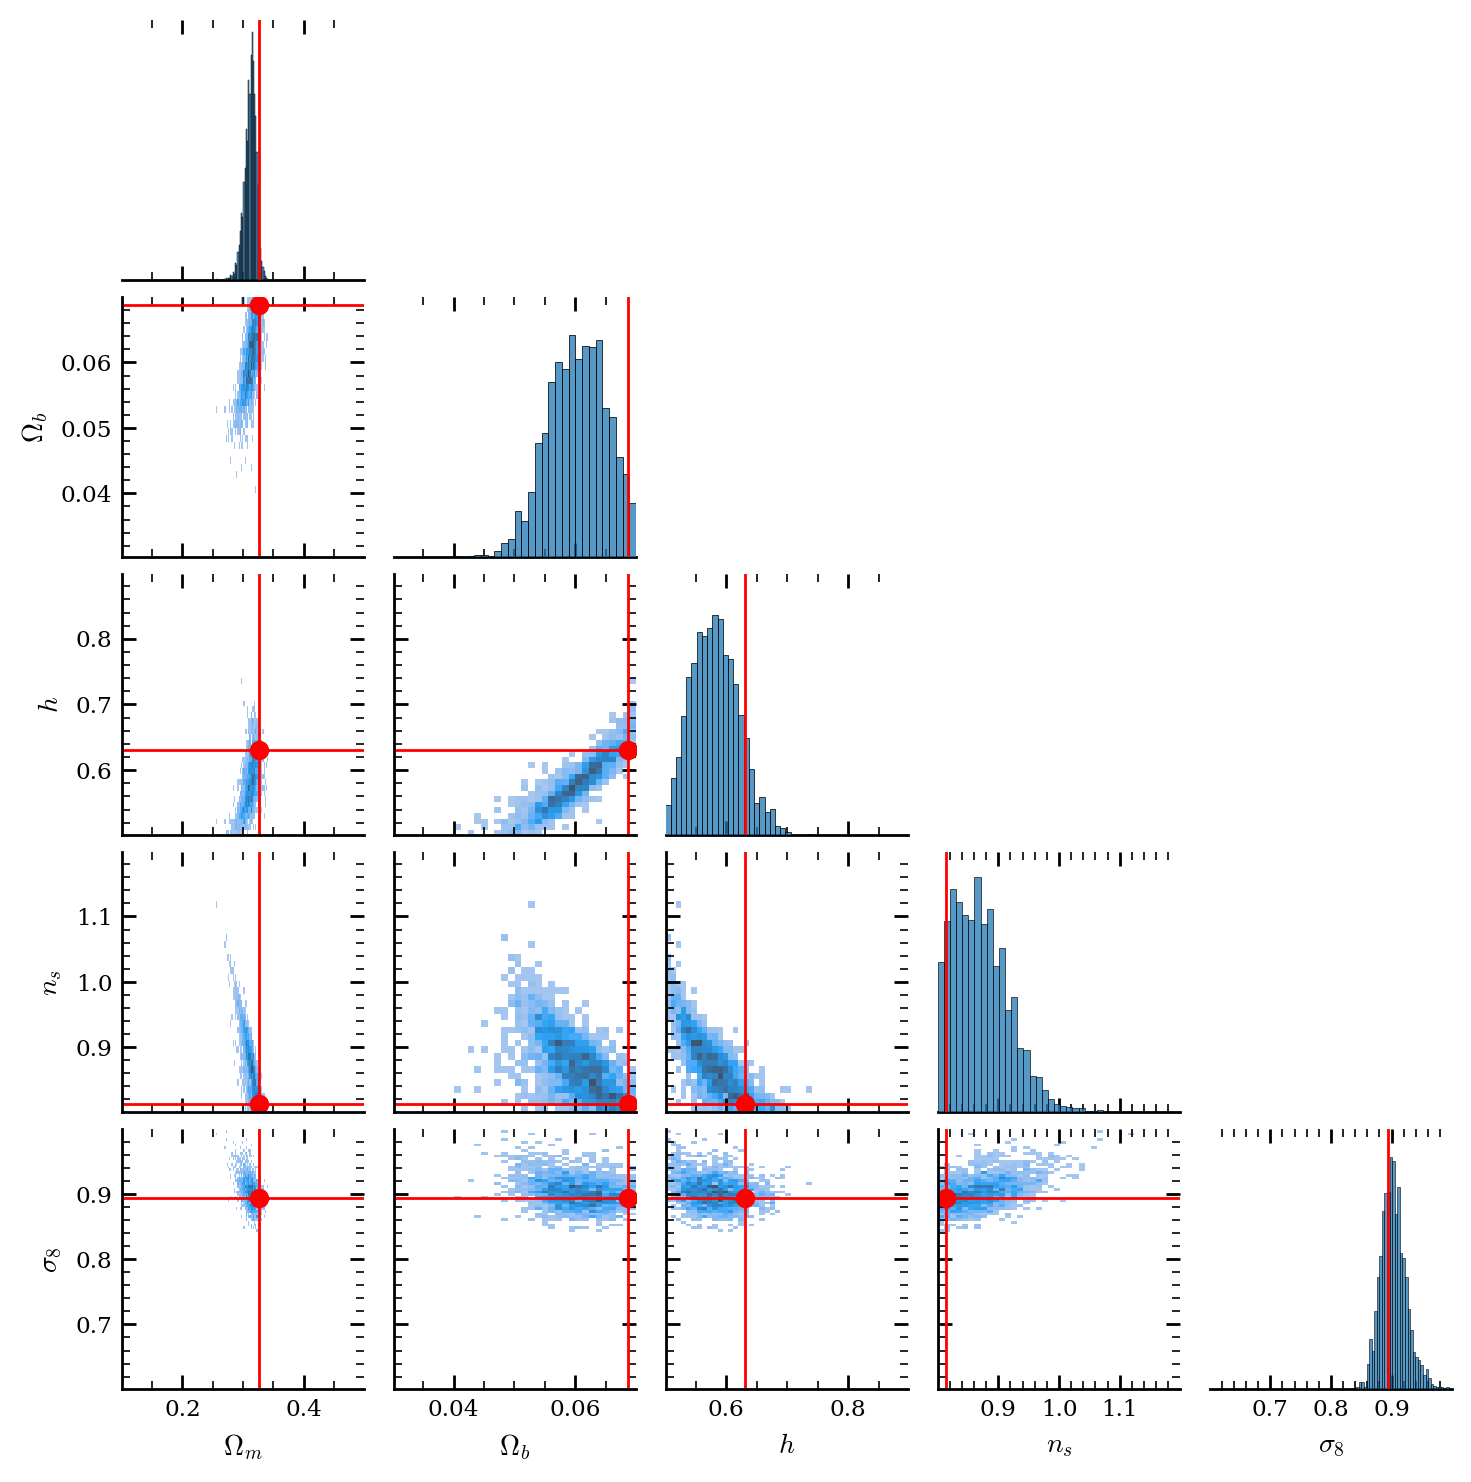

In [9]:
from tools import plot_true_vals, set_boundaries

# Predict on a random test point
ind = 0
x0 = torch.Tensor(xtest[ind]).to(device)
y0 = ytest[ind]
samp0 = posterior.sample(x=x0, shape=(2000,))
samp0 = pd.DataFrame(samp0, columns=names)

g = sns.pairplot(
    samp0,
    vars=names,
    kind='hist',
    corner=True,
    height=1.5
    # plot_kws={'alpha': 0.5, 'levels': [0.05, 0.36, 1], 'fill': True},  # for kde plot
)

plot_true_vals(g, y0, color='r', lw=1)
set_boundaries(g, yrange)

## Load an observed summary

In [10]:
# Load observed data
nbody = 'quijote3gpch'
sim = 'nbody'
save_dir = join(wdir, nbody, sim, 'models')
modelpath = join(save_dir, tracer, summary, f'kmin-{kmin}_kmax-{kmax}')

xobs = np.load(join(modelpath, 'x_test.npy'))
yobs = np.load(join(modelpath, 'theta_test.npy'))
xid = np.load(join(modelpath, 'ids_test.npy'))

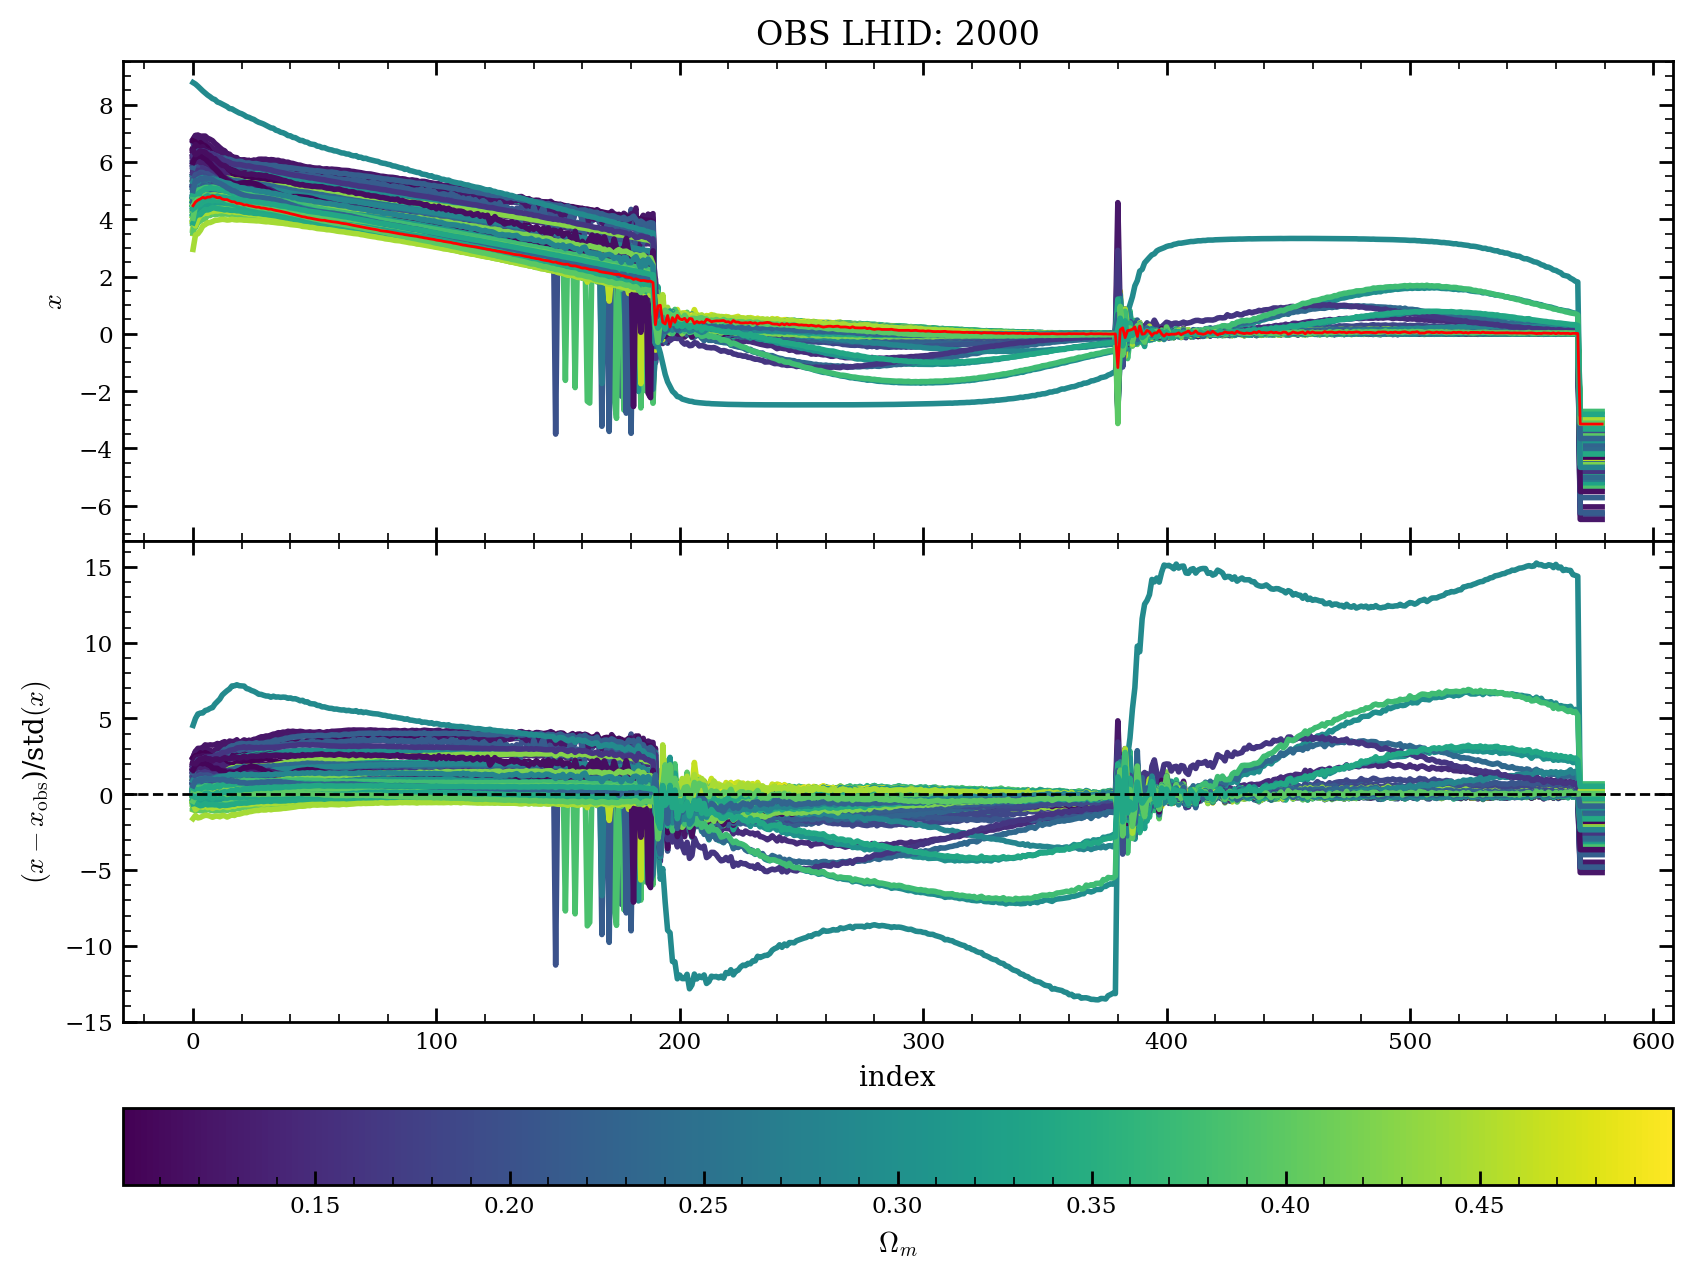

In [12]:
ss = 10
ind = 0

f, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                      gridspec_kw=dict(hspace=0., height_ratios=[1, 1]))

par = ytest[:, 0]
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=par.min(), vmax=par.max())

ax = axs[0]
for i in range(0, len(xtest), ss):
    ax.plot(xtest[i], color=cmap(norm(par[i])))
ax.plot(xobs[ind], 'r-', lw=1)
ax.set(ylabel=r'$x$')
ax.set_title(f'OBS LHID: {xid[ind]}')

ax = axs[1]
for i in range(0, len(xtest), ss):
    ax.plot((xtest[i]-xobs[ind])/np.std(xtest, axis=0),
            color=cmap(norm(par[i])))
ax.axhline(0, c='k', ls='--', lw=1)
ax.set(xlabel='index', ylabel=r'$(x - x_{\rm obs}$)/std$(x)$')

cbar = f.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                  ax=axs, orientation='horizontal', pad=0.07)
cbar.set_label(r'$\Omega_m$')

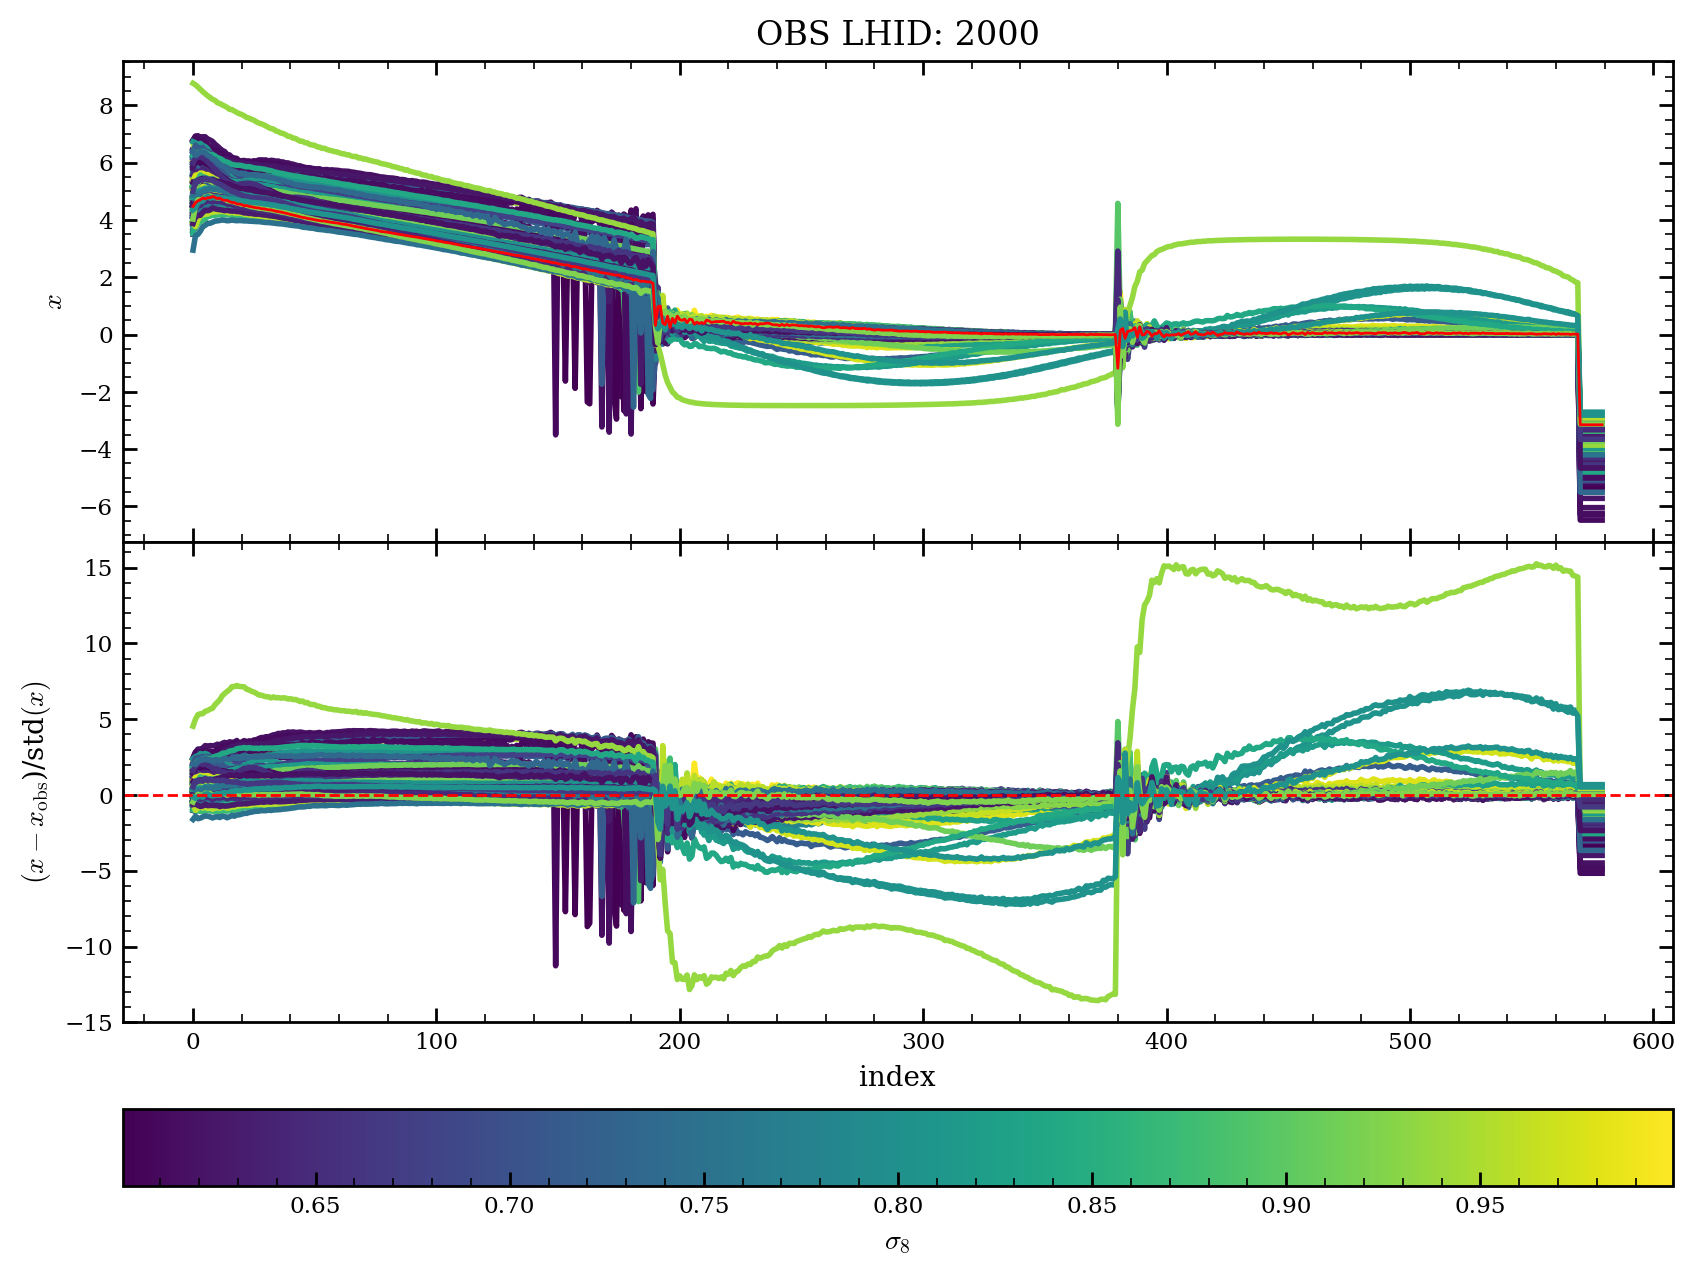

In [13]:
import matplotlib.colors as mcolors

ss = 10
ind = 0

f, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                      gridspec_kw=dict(hspace=0., height_ratios=[1, 1]))

par = ytest[:, 4]
cmap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=par.min(), vmax=par.max())

ax = axs[0]
for i in range(0, len(xtest), ss):
    ax.plot(xtest[i], color=cmap(norm(par[i])))
ax.plot(xobs[ind], 'r-', lw=1)
ax.set(ylabel=r'$x$')
ax.set_title(f'OBS LHID: {xid[ind]}')

ax = axs[1]
for i in range(0, len(xtest), ss):
    ax.plot((xtest[i]-xobs[ind])/np.std(xtest, axis=0),
            color=cmap(norm(par[i])))
ax.axhline(0, c='r', ls='--', lw=1)
ax.set(xlabel='index', ylabel=r'$(x - x_{\rm obs}$)/std$(x)$')

cbar = f.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
                  ax=axs, orientation='horizontal', pad=0.07)
cbar.set_label(r'$\sigma_8$')

INFO:root:Sampling models with [231, 223, 221, 199, 193, 190, 189, 188, 187, 184] samples each.
Drawing 231 posterior samples: 461it [00:00, 17321.59it/s]            
Drawing 223 posterior samples: 396it [00:00, 15031.99it/s]            
Drawing 221 posterior samples: 439it [00:00, 5756.67it/s]             
Drawing 199 posterior samples: 353it [00:00, 19147.12it/s]            
Drawing 193 posterior samples: 369it [00:00, 21100.18it/s]            
Drawing 190 posterior samples: 377it [00:00, 18021.20it/s]            
Drawing 189 posterior samples: 368it [00:00, 19243.04it/s]            
Drawing 188 posterior samples: 371it [00:00, 21816.24it/s]            
Drawing 187 posterior samples: 354it [00:00, 21123.08it/s]            
Drawing 184 posterior samples: 100%|██████████| 184/184 [00:00<00:00, 21323.83it/s]


Text(0.5, 0.98, 'OBS LHID: 2000, galaxy nbar+zPk0+zPk2+zPk4, $k\\in[0.0,0.4]$,')

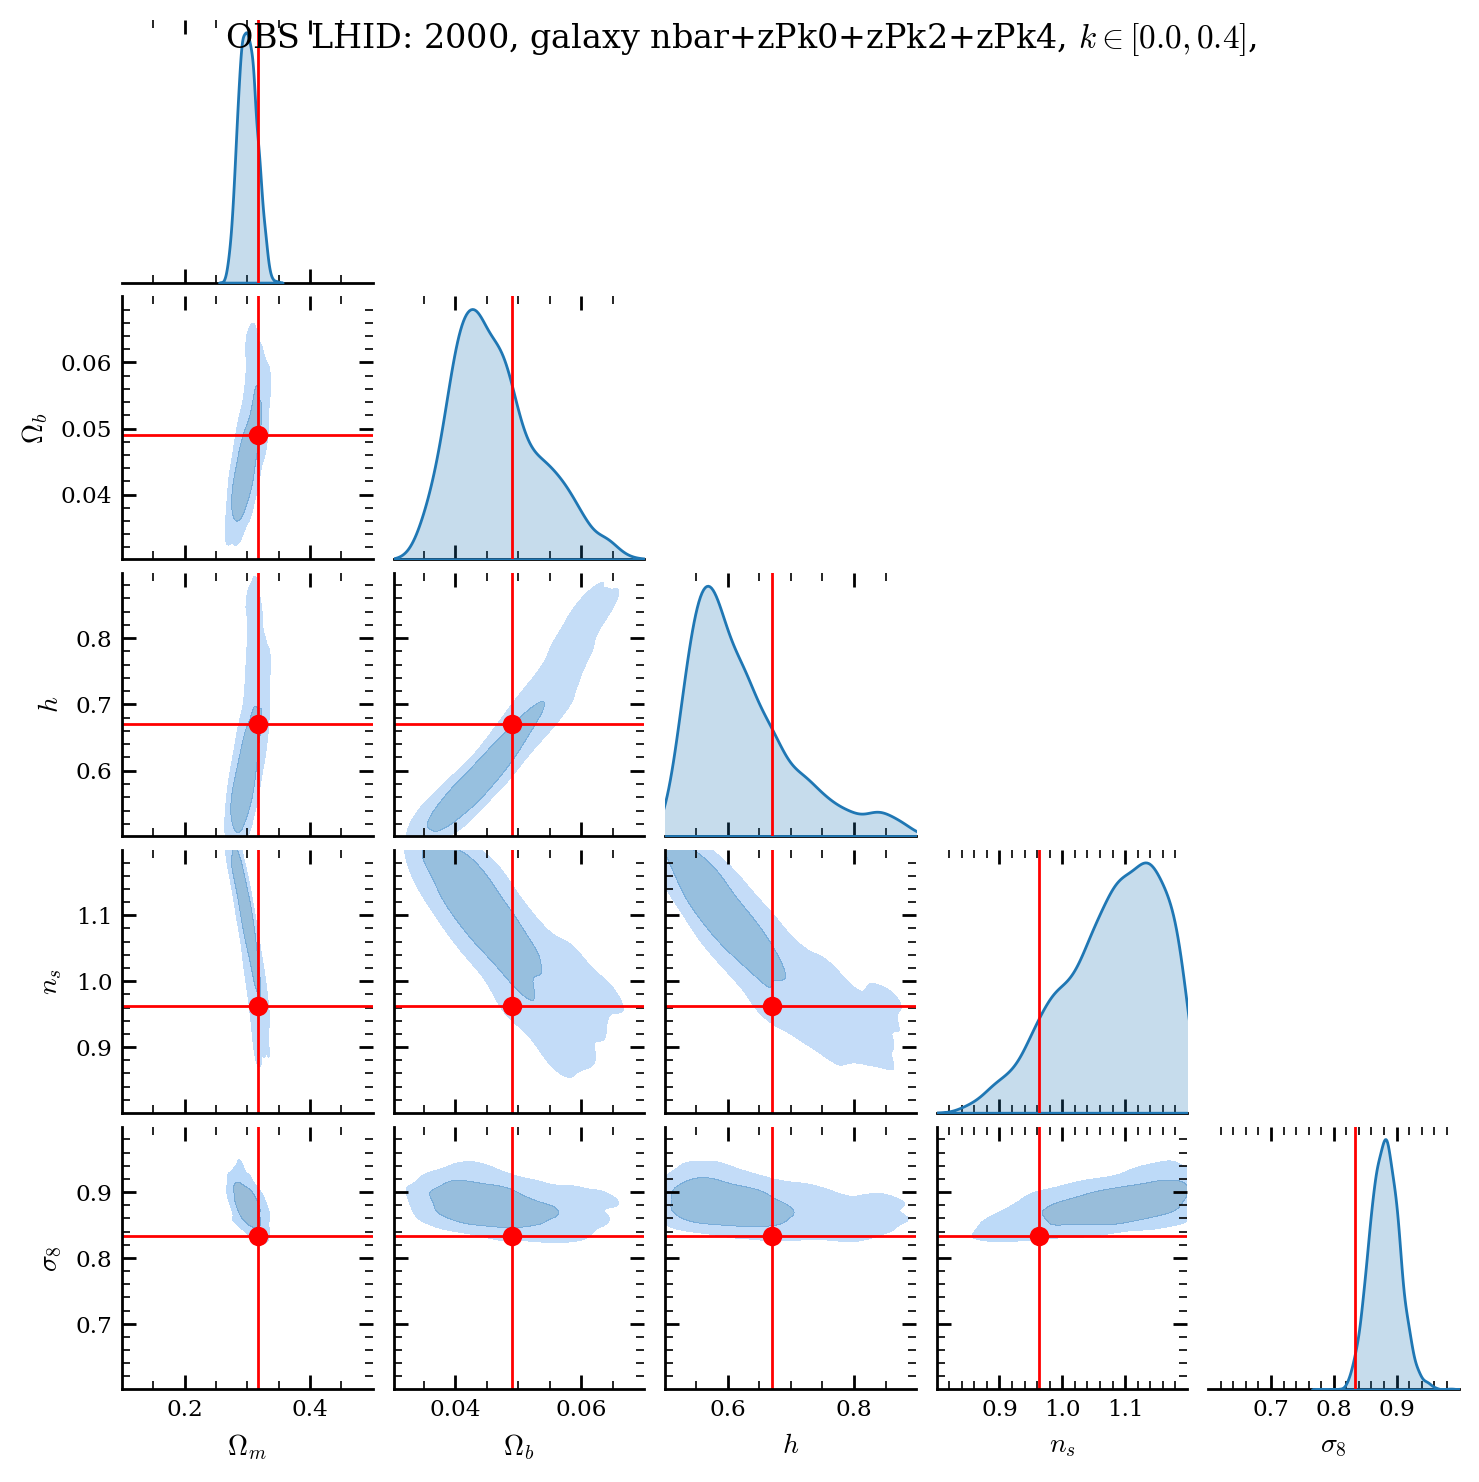

In [14]:
from tools import plot_true_vals, set_boundaries

# Predict on a random test point
ind = 0
samp0 = posterior.sample(x=xobs[ind], shape=(2000,)).to('cpu')
samp0 = pd.DataFrame(samp0, columns=names)


g = sns.pairplot(
    samp0,
    vars=names,
    kind='kde',
    plot_kws={'alpha': 0.5, 'levels': [
        0.05, 0.36, 1], 'fill': True, 'common_norm': False},
    corner=True,
    height=1.5
)
plot_true_vals(g, yobs[ind], color='r', lw=1)
set_boundaries(g, yrange)

g.fig.suptitle(f'OBS LHID: {xid[ind]}, {tracer} ' +
               '+'.join(summaries) + f', $k\in[{kmin},{kmax}]$,')

In [16]:
samps = []
for xin in tqdm(xobs):
    samp = posterior.sample(x=xin, shape=(
        1000,), show_progress_bars=False).to('cpu')
    samps.append(samp)
samps = np.array(samps)
trues = np.array(yobs)

100%|██████████| 5/5 [00:00<00:00,  7.79it/s]


Text(0.5, 0.98, 'galaxy nbar+zPk0+zPk2+zPk4 predictions')

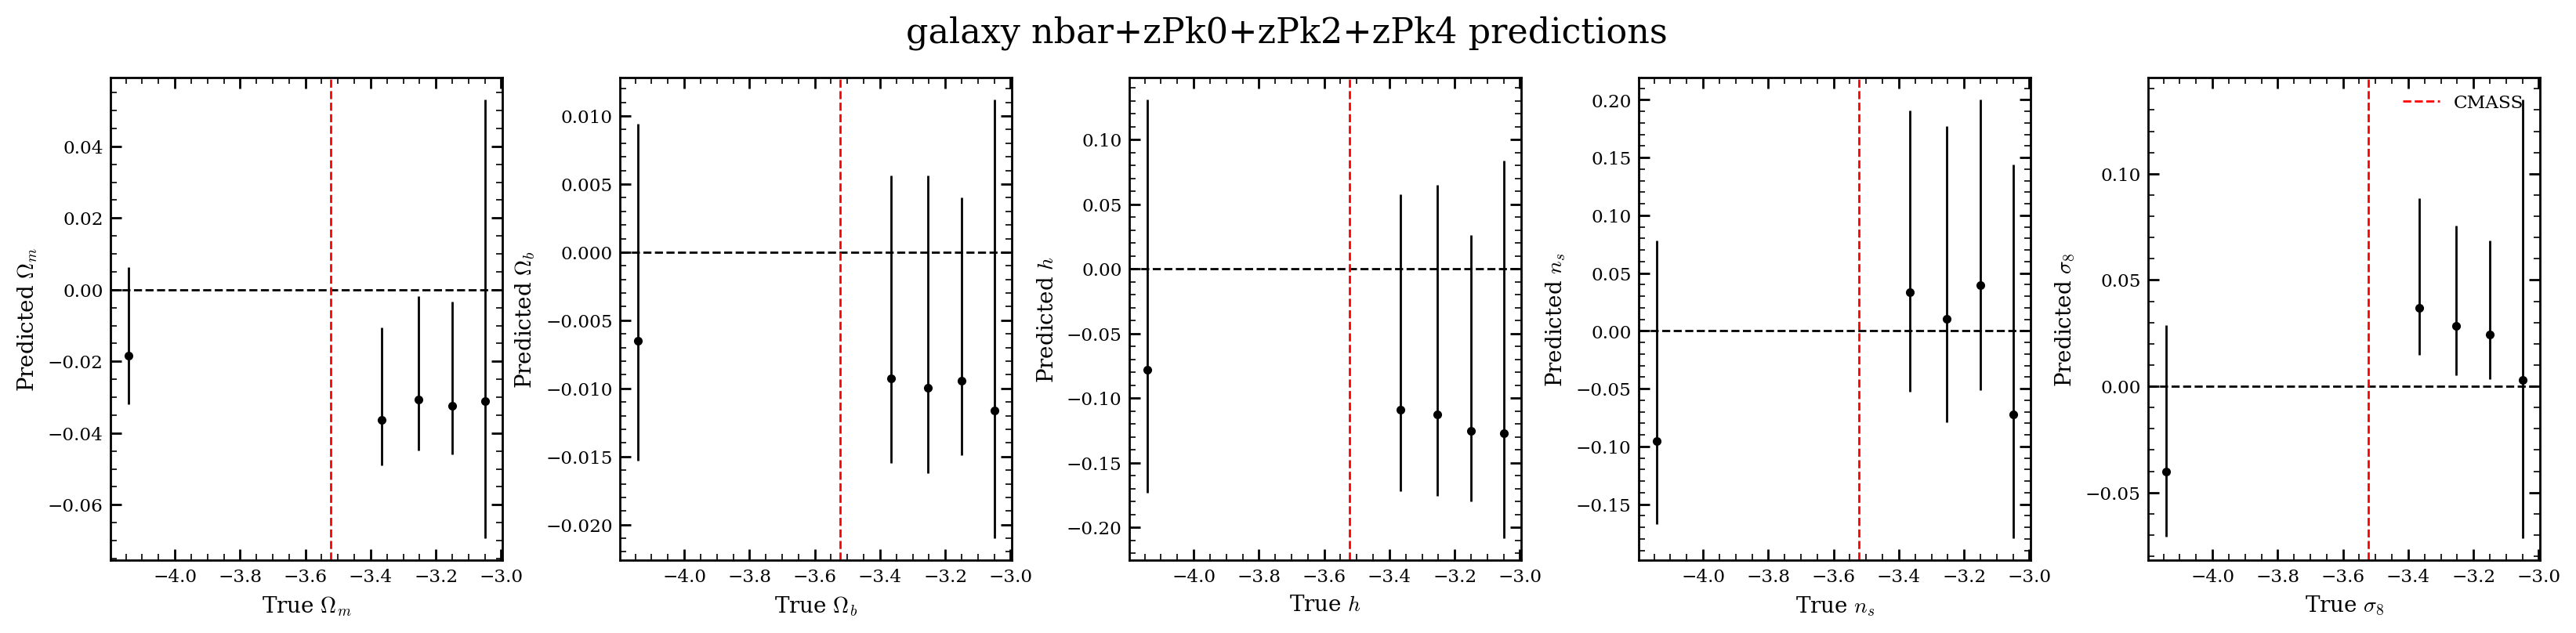

In [27]:
# plot over multiple HOD realizations
if 'nbar' not in summaries:
    raise ValueError('Cell only works for nbar summary')

N = len(names)
H, W = N//5, 5
f, axs = plt.subplots(H, W, figsize=(4*W, 4*H), gridspec_kw=dict(wspace=0.3))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i >= N:
        ax.axis('off')
        continue
    _x = xobs[:, -1]
    p = np.percentile(samps[:, :, i], [50, 16, 84], axis=1)
    p -= trues[:, i]
    ax.axhline(0, color='k', ls='--', lw=1)
    ax.axvline(nbar_CMASS, color='r', ls='--', lw=1, label='CMASS')
    ax.plot(_x, p[1], 'k.')
    ax.errorbar(_x, p[1], yerr=[p[0]-p[1], p[2]-p[1]],
                fmt='none', ecolor='k', elinewidth=1)
    ax.set(xlabel=f'True {names[i]}', ylabel=f'Predicted {names[i]}')
ax.legend()
f.suptitle(f'{tracer} {summary} predictions', fontsize=16)